In [49]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix

In [13]:
df = pd.read_csv("Twitter_Data.csv/Twitter_Data.csv")

In [14]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [16]:
print(df.shape)
print(df.columns)
print(df.info())

(162980, 2)
Index(['clean_text', 'category'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB
None


In [20]:
print(df['clean_text'].head(10))
print(df['category'].value_counts())

0    when modi promised “minimum government maximum...
1    talk all the nonsense and continue all the dra...
2    what did just say vote for modi  welcome bjp t...
3    asking his supporters prefix chowkidar their n...
4    answer who among these the most powerful world...
5             kiya tho refresh maarkefir comment karo 
6    surat women perform yagna seeks divine grace f...
7    this comes from cabinet which has scholars lik...
8    with upcoming election india saga going import...
9                           gandhi was gay does modi  
Name: clean_text, dtype: object
category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64


In [21]:
df.isnull().sum()
df = df.dropna()
print(df.shape)

(162969, 2)


In [23]:
df.isnull().sum()

clean_text    0
category      0
dtype: int64

In [26]:
def new_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['new_text'] = df['clean_text'].apply(new_text)
df[['clean_text', 'new_text']].head()

,clean_text,new_text
0,when modi promised “minimum government maximum...,when modi promised minimum government maximum ...
1,talk all the nonsense and continue all the dra...,talk all the nonsense and continue all the dra...
2,what did just say vote for modi welcome bjp t...,what did just say vote for modi welcome bjp t...
3,asking his supporters prefix chowkidar their n...,asking his supporters prefix chowkidar their n...
4,answer who among these the most powerful world...,answer who among these the most powerful world...


In [29]:
X = df['new_text']
y = df['category']
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state = 23)
print(X_train.shape, X_test.shape)

(130375,) (32594,)


In [46]:
tfidf = TfidfVectorizer(max_features = 7000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(130375, 7000)


In [47]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_train_tfidf, y_train)

print("model Train succesfully")

model Train succesfully


In [48]:
y_pred = model.predict(X_test_tfidf)

print(f" Accuracy:, {accuracy_score(y_test, y_pred)}")

print(classification_report(y_test, y_pred))

 Accuracy:, 0.9275019942320673
              precision    recall  f1-score   support

        -1.0       0.92      0.83      0.87      7230
         0.0       0.92      0.98      0.95     11100
         1.0       0.94      0.94      0.94     14264

    accuracy                           0.93     32594
   macro avg       0.93      0.91      0.92     32594
weighted avg       0.93      0.93      0.93     32594



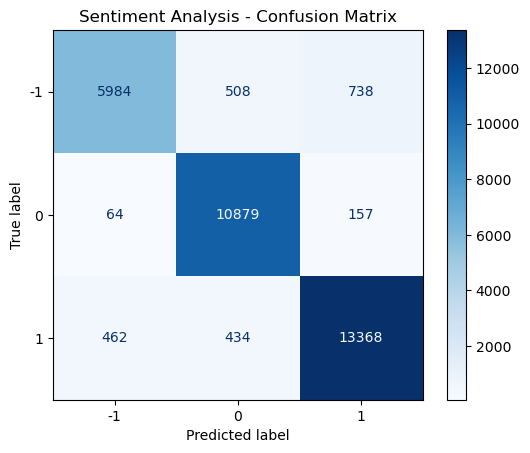

In [51]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [-1, 0, 1])
disp.plot(cmap = 'Blues')
plt.title('Sentiment Analysis - Confusion Matrix')
plt.show()
                            